# Dead Leaves GMM Synthetic Objects

Generate `dead_leaves_reim_gmm` objects from experimental data and visually compare Re-Im distributions.

In [2]:
import sys, os
sys.path.insert(0, os.path.abspath('../..'))

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from glob import glob

from ptycho_torch.datagen.objects import (
    create_dead_leaves_reim_gmm,
    create_dead_leaves_reim_ot,
    create_dead_leaves_v3,
    create_white_noise_clustered_reim,
    create_density_histogram_reim,
    compute_reim_statistics,
    fit_gmm_from_objects,
)

## 1. Load experimental object

In [3]:
npz_path = glob('../../data/2id_2025_S35_multiprobe_128/'+'*.npz')[0]

ref_obj = np.load(npz_path)['objectGuess']
print(f'Object: shape={ref_obj.shape}, dtype={ref_obj.dtype}')
print(f'Amplitude range: [{np.abs(ref_obj).min():.4f}, {np.abs(ref_obj).max():.4f}]')
print(f'Re range: [{ref_obj.real.min():.4f}, {ref_obj.real.max():.4f}]')
print(f'Im range: [{ref_obj.imag.min():.4f}, {ref_obj.imag.max():.4f}]')

Object: shape=(1088, 2562), dtype=complex64
Amplitude range: [0.0013, 1.4059]
Re range: [-1.3083, 1.3960]
Im range: [-1.2255, 1.2606]


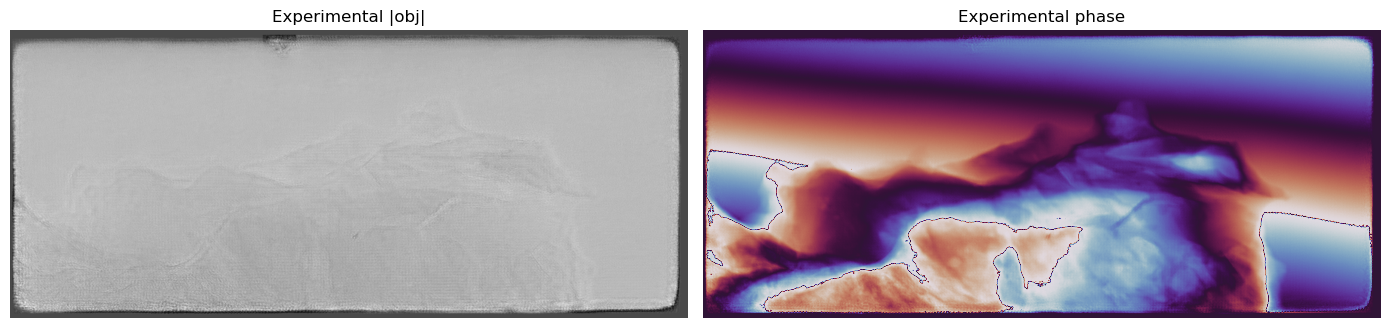

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].imshow(np.abs(ref_obj), cmap='gray')
axes[0].set_title('Experimental |obj|')
axes[0].axis('off')

axes[1].imshow(np.angle(ref_obj), cmap='twilight', vmin=-np.pi, vmax=np.pi)
axes[1].set_title('Experimental phase')
axes[1].axis('off')

plt.tight_layout()
plt.show()

(array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [1., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]]),
 array([-1.09423828, -0.45995911,  0.17432007,  0.80859924,  1.44287842,
         2.07715759,  2.71143677,  3.34571594,  3.97999512,  4.61427429,
         5.24855347,  5.88283264,  6.51711182,  7.15139099,  7.78567017,
         8.41994934,  9.05422852,  9.68850769, 10.32278687, 10.95706604,
        11.59134521, 12.22562439, 12.85990356, 13.49418274, 14.12846191,
        14.76274109, 15.39702026, 16.03129944, 16.66557861, 17.29985779,
        17.93413696, 18.56841614, 19.20269531, 19.83697449, 20.47125366,
        21.10553284, 21.73981201, 22.37409119, 23.00837036, 23.64264954,
        24.27692871, 24.91120789, 25.54548706, 26.17976624, 26.81404541,
        27.44832458, 28.08260376, 28.71688293, 29.35116211, 29.98544128,
        30.61972046])

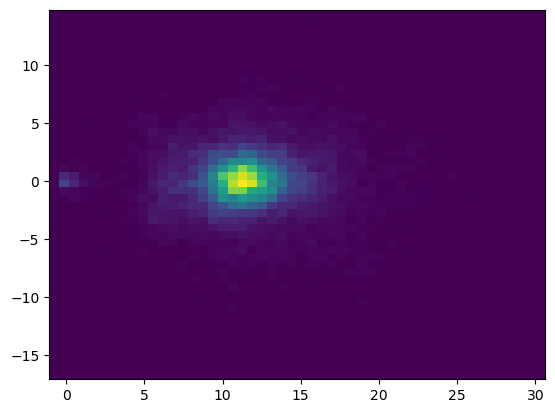

In [5]:
# Check the scan pattern distribution
loaded_obj = np.load(npz_path)
xcoords = loaded_obj['xcoords']
ycoords =loaded_obj['ycoords']

xcoord_diff = xcoords[1:] - xcoords[0:-1]
ycoord_diff = ycoords[1:] - ycoords[:-1]

xcoord_diff_corr = xcoord_diff[np.abs(xcoord_diff) < 50]
ycoord_diff_corr = ycoord_diff[np.abs(xcoord_diff) < 50]


plt.hist2d(xcoord_diff_corr, ycoord_diff_corr, bins = 50)

## 2. Histogram and GMM fit

In [6]:
exp_obj_list = [ref_obj]

histogram, re_edges, im_edges = create_density_histogram_reim(
    exp_obj_list, origin_mask_radius=0.4,
)

stats = compute_reim_statistics(exp_obj_list)

gmm_params = fit_gmm_from_objects(
    exp_obj_list, n_clusters=4, origin_mask_radius=0.4,
)

print(f'\nRe-Im statistics:')
for k in ['re_mean', 'im_mean', 're_std', 'im_std', 'correlation']:
    print(f'  {k}: {stats[k]:.4f}')
print(f'GMM clusters: {gmm_params["n_clusters"]}')
print(f'Cluster weights: {gmm_params["weights"].round(3)}')

Re-Im histogram vacuum mode: Re=0.4102, Im=0.0055
n_clusters is: 4
GMM fit: K=4, centers=([-0.594, 0.555, -0.574, 0.715], [0.674, -0.775, -0.664, 0.264]), weights=[0.212, 0.2, 0.219, 0.369], vacuum=(0.715, 0.264)

Re-Im statistics:
  re_mean: 0.1260
  im_mean: -0.0590
  re_std: 0.6812
  im_std: 0.6719
  correlation: -0.0443
GMM clusters: 4
Cluster weights: [0.212 0.2   0.219 0.369]


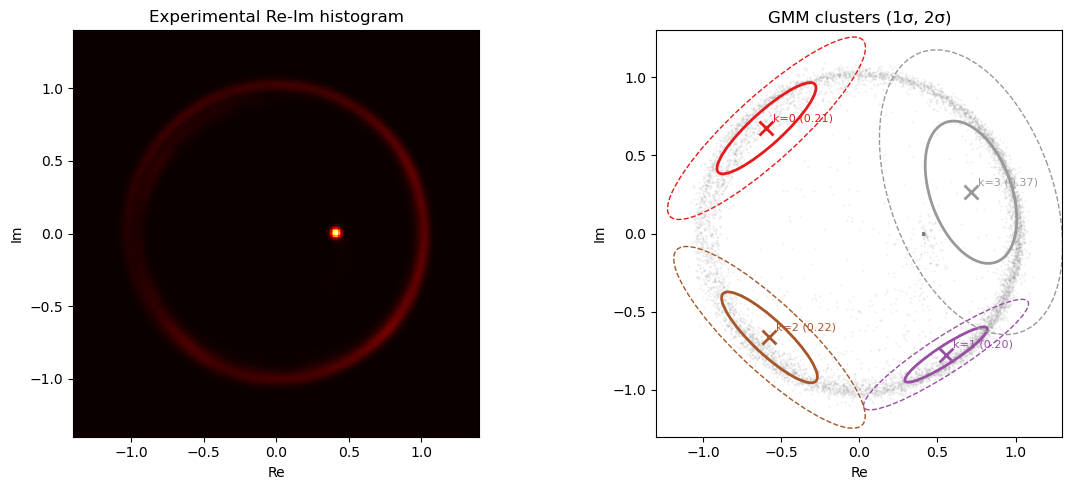

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: 2D histogram
ax = axes[0]
re_c = 0.5 * (re_edges[:-1] + re_edges[1:])
im_c = 0.5 * (im_edges[:-1] + im_edges[1:])
ax.pcolormesh(re_c, im_c, histogram.T, cmap='hot')
ax.set_xlabel('Re')
ax.set_ylabel('Im')
ax.set_title('Experimental Re-Im histogram')
ax.set_aspect('equal')

# Right: scatter + GMM ellipses
ax = axes[1]
flat = ref_obj.ravel()
subsample = flat[::max(1, len(flat) // 8000)]
ax.scatter(subsample.real, subsample.imag, s=0.2, alpha=0.15, c='gray', rasterized=True)

means = gmm_params['means']
covs = gmm_params['covariances']
weights = gmm_params['weights']
colors = plt.cm.Set1(np.linspace(0, 1, len(weights)))

for k in range(len(weights)):
    eigvals, eigvecs = np.linalg.eigh(covs[k])
    angle = np.degrees(np.arctan2(eigvecs[1, 1], eigvecs[0, 1]))
    for n_std in [1, 2]:
        ell = Ellipse(
            xy=means[k], width=2 * n_std * np.sqrt(eigvals[1]),
            height=2 * n_std * np.sqrt(eigvals[0]), angle=angle,
            edgecolor=colors[k], facecolor='none',
            linewidth=2 if n_std == 1 else 1,
            linestyle='-' if n_std == 1 else '--',
        )
        ax.add_patch(ell)
    ax.plot(means[k, 0], means[k, 1], 'x', color=colors[k], markersize=10, markeredgewidth=2)
    ax.annotate(f'k={k} ({weights[k]:.2f})', means[k], fontsize=8,
                color=colors[k], textcoords='offset points', xytext=(5, 5))

ax.set_xlabel('Re')
ax.set_ylabel('Im')
ax.set_title('GMM clusters (1\u03c3, 2\u03c3)')
ax.set_aspect('equal')
ax.set_xlim(-1.3, 1.3)
ax.set_ylim(-1.3, 1.3)

plt.tight_layout()
plt.show()

## 3. Generate synthetic objects (multi-method comparison)

In [ ]:
from ptycho_torch.datagen.datagen import extract_scan_steps, compute_canvas_size

N = 128
diff_per_object = 7000

# Derive object canvas size from reference scan step sizes
scan_steps = extract_scan_steps(xcoords, ycoords)
image_size = compute_canvas_size(diff_per_object, scan_steps, N)
print(f"Reference scan steps: x={scan_steps['x_step']:.3f}, y={scan_steps['y_step']:.3f}")
print(f"Auto canvas size: {image_size}")

# Shared GMM / perturbation args
base_obj_arg = {
    'gmm_params': gmm_params,
    'perturbation_mode': 'physical',
    'phase_jitter_std': 0.02,
    'amplitude_scale_std': 0.01,
    'center_jitter_std': 0.015,
    'weight_dirichlet_conc': 5.0,
    'clip_range': (-1.2, 1.2),
    'origin_mask_radius': 0.5,
    'texture_scale': 6.5
}

ot_arg = {
    'histogram': histogram,
    're_range': (stats['re_min'], stats['re_max']),
    'im_range': (stats['im_min'], stats['im_max']),
    'vacuum_re': gmm_params['vacuum_reim'][0],
    'vacuum_im': gmm_params['vacuum_reim'][1],
    'ot_correlation_scale': 48,
    'r_min': 2,
    'r_max': 60
}

methods = {
    'dead_leaves_gmm': lambda: create_dead_leaves_reim_gmm(image_size, base_obj_arg),
    'dead_leaves_hist': lambda: create_dead_leaves_v3(
        image_size, {**base_obj_arg, 'mode': 'histogram'}, histogram=histogram,
    ),
    'white_noise_gmm': lambda: create_white_noise_clustered_reim(image_size, base_obj_arg),
    'dead_leaves_ot': lambda: create_dead_leaves_reim_ot(
        image_size, {**base_obj_arg, **ot_arg, 'target_distribution': 'histogram'}, N=N,
    ),
}

synth_objects = {}
for name, gen_fn in methods.items():
    obj = gen_fn()
    synth_objects[name] = obj
    print(f'{name}: shape={obj.shape}, amp=[{np.abs(obj).min():.3f}, {np.abs(obj).max():.3f}]')

method_names = list(synth_objects.keys())

Reference scan steps: x=11.389, y=11.461
Auto canvas size: (1080, 1074)
create_dead_leaves_reim_gmm: generated (1080, 1074) object, K=4, 41500 leaves
dead_leaves_gmm: shape=(1080, 1074), amp=[0.002, 1.352]
create_dead_leaves_v3 (mode=histogram): generated (1080, 1074) object
dead_leaves_hist: shape=(1080, 1074), amp=[0.001, 1.131]
white_noise_gmm: shape=(1080, 1074), amp=[0.000, 1.697]
create_dead_leaves_reim_ot: generated (1080, 1074) object, target=histogram, 11000 leaves
dead_leaves_ot: shape=(1080, 1074), amp=[0.009, 1.169]


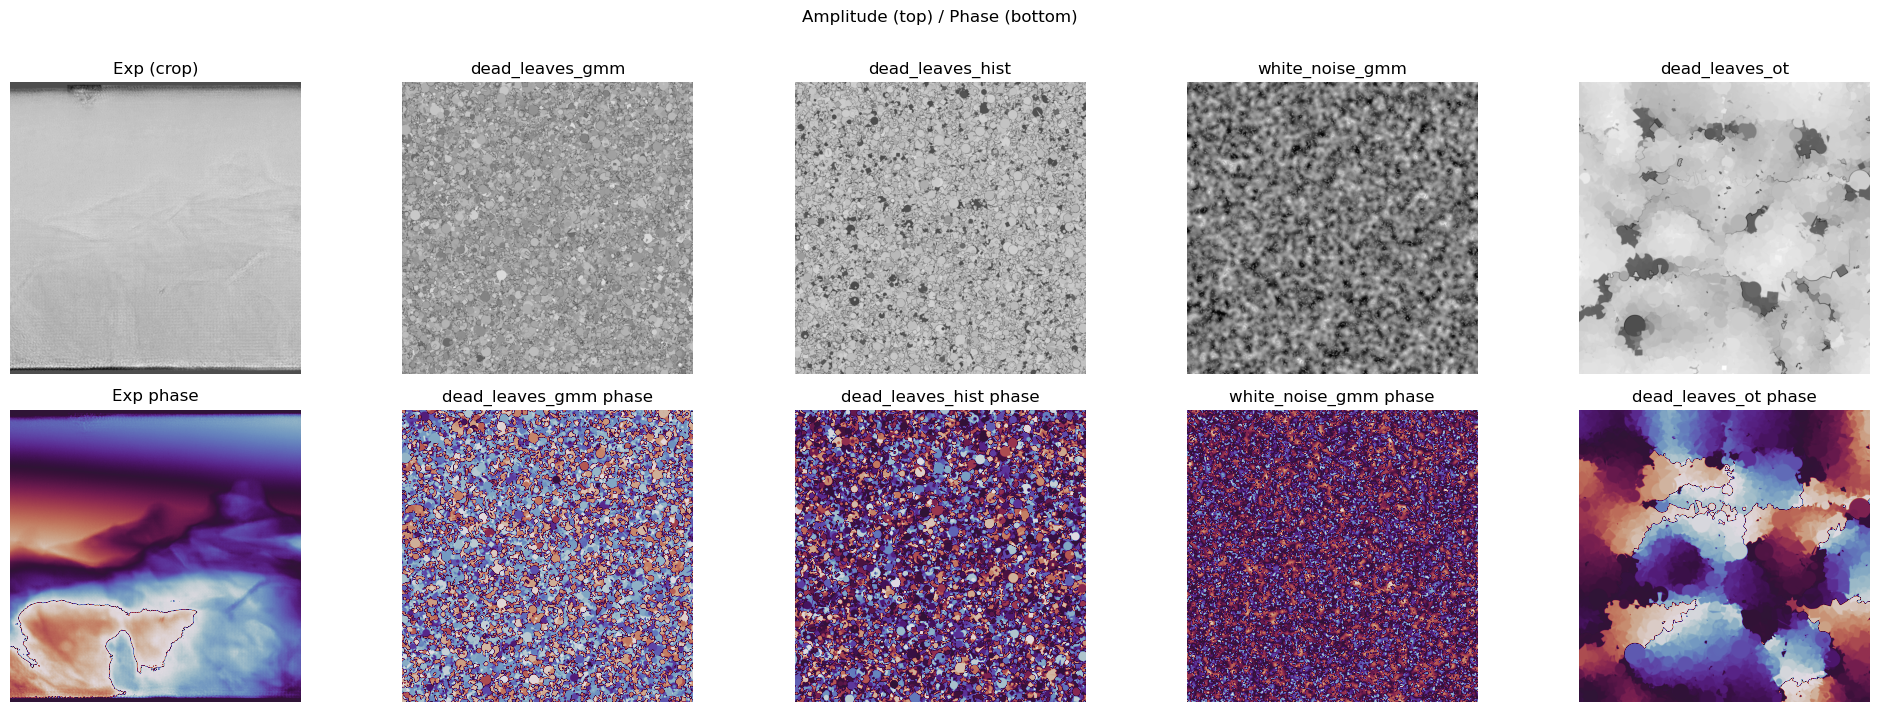

In [19]:
n_methods = len(method_names)
fig, axes = plt.subplots(2, 1 + n_methods, figsize=(4 * (1 + n_methods), 7))

h, w = image_size
exp_crop = ref_obj[
    ref_obj.shape[0] // 2 - h // 2 : ref_obj.shape[0] // 2 + h // 2,
    ref_obj.shape[1] // 2 - w // 2 : ref_obj.shape[1] // 2 + w // 2,
]

axes[0, 0].imshow(np.abs(exp_crop), cmap='gray')
axes[0, 0].set_title('Exp (crop)')
axes[0, 0].axis('off')
axes[1, 0].imshow(np.angle(exp_crop), cmap='twilight', vmin=-np.pi, vmax=np.pi)
axes[1, 0].set_title('Exp phase')
axes[1, 0].axis('off')

for i, name in enumerate(method_names):
    obj = synth_objects[name]
    axes[0, i + 1].imshow(np.abs(obj), cmap='gray')
    axes[0, i + 1].set_title(name)
    axes[0, i + 1].axis('off')
    axes[1, i + 1].imshow(np.angle(obj), cmap='twilight', vmin=-np.pi, vmax=np.pi)
    axes[1, i + 1].set_title(f'{name} phase')
    axes[1, i + 1].axis('off')

plt.suptitle('Amplitude (top) / Phase (bottom)', y=1.01)
plt.tight_layout()
plt.show()

## 4. Re-Im distribution comparison

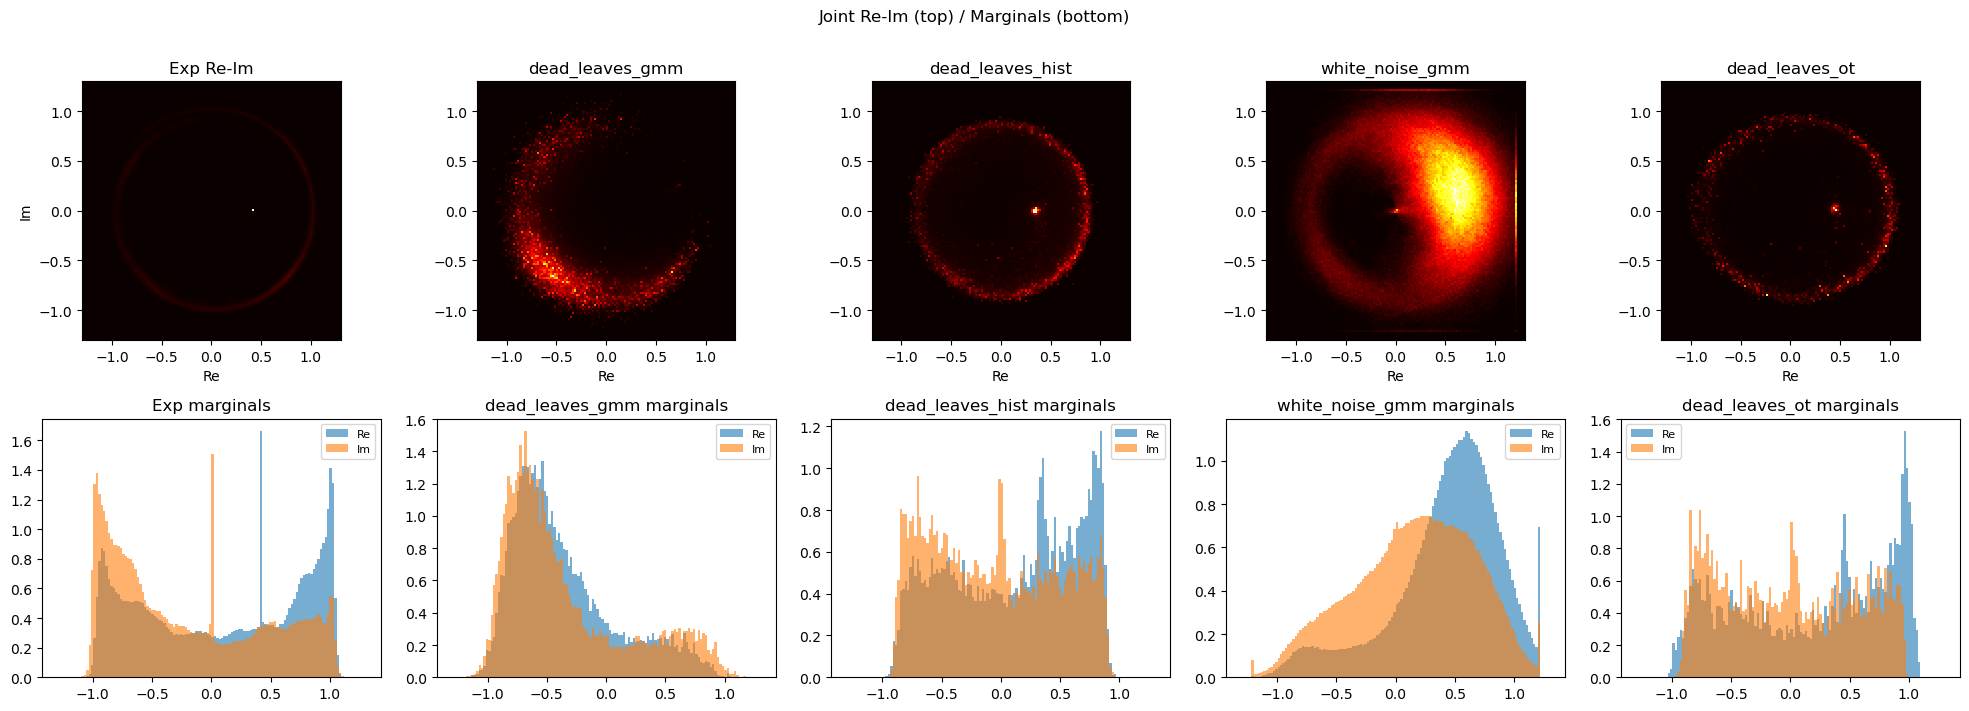

In [10]:
fig, axes = plt.subplots(2, 1 + n_methods, figsize=(4 * (1 + n_methods), 7))
hist_range = [[-1.3, 1.3], [-1.3, 1.3]]
bins = 128

axes[0, 0].hist2d(exp_crop.real.ravel(), exp_crop.imag.ravel(),
                  bins=bins, range=hist_range, cmap='hot')
axes[0, 0].set_title('Exp Re-Im')
axes[0, 0].set_xlabel('Re')
axes[0, 0].set_ylabel('Im')
axes[0, 0].set_aspect('equal')

axes[1, 0].hist(exp_crop.real.ravel(), bins=bins, range=(-1.3, 1.3),
                alpha=0.6, label='Re', density=True)
axes[1, 0].hist(exp_crop.imag.ravel(), bins=bins, range=(-1.3, 1.3),
                alpha=0.6, label='Im', density=True)
axes[1, 0].set_title('Exp marginals')
axes[1, 0].legend(fontsize=8)

for i, name in enumerate(method_names):
    obj = synth_objects[name]
    axes[0, i + 1].hist2d(obj.real.ravel(), obj.imag.ravel(),
                          bins=bins, range=hist_range, cmap='hot')
    axes[0, i + 1].set_title(f'{name}')
    axes[0, i + 1].set_xlabel('Re')
    axes[0, i + 1].set_aspect('equal')

    axes[1, i + 1].hist(obj.real.ravel(), bins=bins, range=(-1.3, 1.3),
                        alpha=0.6, label='Re', density=True)
    axes[1, i + 1].hist(obj.imag.ravel(), bins=bins, range=(-1.3, 1.3),
                        alpha=0.6, label='Im', density=True)
    axes[1, i + 1].set_title(f'{name} marginals')
    axes[1, i + 1].legend(fontsize=8)

plt.suptitle('Joint Re-Im (top) / Marginals (bottom)', y=1.01)
plt.tight_layout()
plt.show()

## 5. Generate and save synthetic dataset

In [13]:
from ptycho_torch.config_params import DataConfig
from ptycho_torch.datagen.datagen import simulate_multiple_experiments, extract_scan_steps, compute_canvas_size
from ptycho_torch.utils import remove_all_files

# --- Configuration ---
save_dir = '../../data/2id_2025_S54_multiprobe_128_synthetic_dl_ot_20'
n_objects = 4
obj_method = 'dead_leaves_ot'  # or 'dead_leaves_reim_gmm', 'white_noise_clustered_reim'

# Reference for histogram/GMM: npz_path (fitted in section 2)
# Reference for probe + scan step sizes: probe_path (must be same file)
probe_path = '../../data/2id_2025_S35_multiprobe_128/2id_S35_multiprobe_128.npz'

data_config = DataConfig(N=N)

# Extract scan step sizes from probe reference
probe_ref = np.load(probe_path)
probe = probe_ref['probeGuess']
scan_steps = extract_scan_steps(probe_ref['xcoords'], probe_ref['ycoords'])
image_size = compute_canvas_size(diff_per_object, scan_steps, N)

print(f"Probe scan steps: x={scan_steps['x_step']:.3f}, y={scan_steps['y_step']:.3f}, "
      f"ratio={scan_steps['step_ratio']:.3f}")
print(f"Auto canvas size: {image_size}")

probe_list = [probe] * n_objects
probe_name_idx = [0] * n_objects
probe_arg = {'probe_name_idx': probe_name_idx, 'beamstop_diameter': 4}

# OT ARG
ot_arg = {
    'histogram': histogram,
    're_range': (stats['re_min'], stats['re_max']),
    'im_range': (stats['im_min'], stats['im_max']),
    'vacuum_re': gmm_params['vacuum_reim'][0],
    'vacuum_im': gmm_params['vacuum_reim'][1],
    'ot_correlation_scale': 20,
}

# Generate synthetic objects at auto-computed canvas size
gen_funcs = {
    'white_noise_clustered_reim': lambda: create_white_noise_clustered_reim(image_size, base_obj_arg),
    'dead_leaves_reim_gmm': lambda: create_dead_leaves_reim_gmm(image_size, base_obj_arg),
    'dead_leaves_reim_hist': lambda: create_dead_leaves_v3(
        image_size, {**base_obj_arg, 'mode': 'histogram'}, histogram=histogram,
    ),
    'dead_leaves_ot': lambda: create_dead_leaves_reim_ot(
            image_size, {**base_obj_arg, **ot_arg, 'target_distribution': 'histogram'}, N=N,
        ),
}

print(f'Generating {n_objects} objects with {obj_method}...')
obj_list = [gen_funcs[obj_method]() for _ in range(n_objects)]

# Prepare output directory
import os
if not os.path.exists(save_dir):
    os.makedirs(save_dir)
else:
    remove_all_files(save_dir)

# Simulate diffraction and save NPZs
simulate_multiple_experiments(
    obj_list, probe_list, diff_per_object,
    image_size, data_config, probe_arg, save_dir,
    scan_step_sizes=scan_steps,
)
print(f'Saved {n_objects} experiments to {save_dir}')

Probe scan steps: x=11.389, y=11.461, ratio=0.994
Auto canvas size: (1080, 1074)
Generating 4 objects with dead_leaves_ot...
create_dead_leaves_reim_ot: generated (1080, 1074) object, target=histogram, 11000 leaves
create_dead_leaves_reim_ot: generated (1080, 1074) object, target=histogram, 11500 leaves
create_dead_leaves_reim_ot: generated (1080, 1074) object, target=histogram, 11000 leaves
create_dead_leaves_reim_ot: generated (1080, 1074) object, target=histogram, 11000 leaves
----Beginning simulation for experiment 0----
Anisotropic grid: nx=84, ny=84, x_step=11.40, y_step=11.47, ratio=0.994 (target=0.994)
Beginning simulation...
Processing 7000 images in batches of 1000...
Concatenating results...
----Finished saving for experiment 0 in 2.5347940921783447 seconds----
----Beginning simulation for experiment 1----
Anisotropic grid: nx=84, ny=84, x_step=11.40, y_step=11.47, ratio=0.994 (target=0.994)
Beginning simulation...
Processing 7000 images in batches of 1000...
Concatenating r

## Sanity check

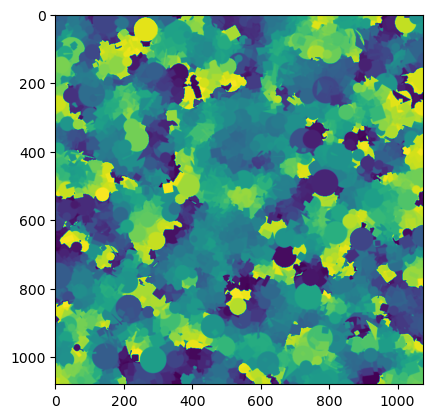

In [18]:
plt.imshow(np.angle(obj_list[0]))

## 6. Cross-dataset synthetic data generation

Extract the (Re, Im) material distribution from one experimental reconstruction and pair it
with the probe from a **different** experiment. This decouples material statistics from the
optical setup, enabling training data that matches a target beamline/probe while borrowing
material knowledge from a better-reconstructed or higher-quality sample.

In [28]:
import sys, os
sys.path.insert(0, os.path.abspath('../..'))

import numpy as np
import matplotlib.pyplot as plt

from ptycho_torch.datagen.objects import (
    create_dead_leaves_reim_gmm,
    create_dead_leaves_v3,
    create_white_noise_clustered_reim,
    create_density_histogram_reim,
    compute_reim_statistics,
    fit_gmm_from_objects,
)
from ptycho_torch.datagen.datagen import simulate_multiple_experiments, extract_scan_steps, compute_canvas_size
from ptycho_torch.config_params import DataConfig
from ptycho_torch.utils import remove_all_files

# ---- User-editable paths ------------------------------------------------
# Source for material (Re, Im) distribution — histogram / GMM fitting
distribution_source_path = '../../data/2id_2025_S54_multiprobe/2id_S54_new.npz'

# Source for probe AND scan step sizes (must be same file)
probe_source_path = '../../data/2id_2025_S54_multiprobe_128/2id_S54_multiprobe_128.npz'

# ---- Generation parameters ----------------------------------------------
N = 128
n_objects = 4
diff_per_object = 7000
obj_method = 'dead_leaves_reim_hist'  # or 'dead_leaves_reim_hist', 'white_noise_clustered_reim'
save_dir = '../../data/2id_2025_S54_multiprobe_128_synthetic_dead_leaves_hist'

# Derive canvas size from probe reference scan steps
probe_ref_data = np.load(probe_source_path)
xd_scan_steps = extract_scan_steps(probe_ref_data['xcoords'], probe_ref_data['ycoords'])
image_size = compute_canvas_size(diff_per_object, xd_scan_steps, N)

print(f"Probe scan steps: x={xd_scan_steps['x_step']:.3f}, y={xd_scan_steps['y_step']:.3f}, "
      f"ratio={xd_scan_steps['step_ratio']:.3f}")
print(f"Auto canvas size: {image_size}")

Probe scan steps: x=11.344, y=11.520, ratio=0.985
Auto canvas size: (1085, 1070)


In [23]:
# Load object from distribution source, probe from target source
dist_obj = np.load(distribution_source_path)['objectGuess']
target_probe = probe_ref_data['probeGuess']

print(f'Distribution source: {os.path.basename(distribution_source_path)}')
print(f'  objectGuess shape={dist_obj.shape}, dtype={dist_obj.dtype}')
print(f'  Re range: [{dist_obj.real.min():.4f}, {dist_obj.real.max():.4f}]')
print(f'  Im range: [{dist_obj.imag.min():.4f}, {dist_obj.imag.max():.4f}]')
print(f'\nProbe source: {os.path.basename(probe_source_path)}')
print(f'  probeGuess shape={target_probe.shape}, dtype={target_probe.dtype}')
assert target_probe.shape[-1] == N and target_probe.shape[-2] == N, \
    f'Probe spatial dims {target_probe.shape[-2:]} do not match N={N}'

# Fit GMM and histogram from distribution source
xd_gmm_params = fit_gmm_from_objects([dist_obj], n_clusters=3, origin_mask_radius=0.4)
xd_histogram, xd_re_edges, xd_im_edges = create_density_histogram_reim([dist_obj], origin_mask_radius=0.4)

print(f'\nGMM clusters: {xd_gmm_params["n_clusters"]}')
print(f'Cluster weights: {xd_gmm_params["weights"].round(3)}')

# Build generation arguments
xd_obj_arg = {
    'gmm_params': xd_gmm_params,
    'perturbation_mode': 'physical',
    'phase_jitter_std': 0.1,
    'amplitude_scale_std': 0.03,
    'center_jitter_std': 0.05,
    'weight_dirichlet_conc': 5.0,
    'clip_range': (-1.2, 1.2),
}

Distribution source: 2id_S54_new.npz
  objectGuess shape=(545, 1281), dtype=complex64
  Re range: [-0.9946, 1.3292]
  Im range: [-1.1486, 1.2075]

Probe source: 2id_S54_multiprobe_128.npz
  probeGuess shape=(10, 128, 128), dtype=complex64
n_clusters is: 3
GMM fit: K=3, centers=([0.337, 0.406, 0.939], [-0.784, 0.833, -0.003]), weights=[0.119, 0.115, 0.766], vacuum=(0.939, -0.003)
Re-Im histogram vacuum mode: Re=1.0117, Im=-0.1258

GMM clusters: 3
Cluster weights: [0.119 0.115 0.766]


### Create a few different objects

In [24]:
methods = {
    'dead_leaves_gmm': lambda: create_dead_leaves_reim_gmm(image_size, xd_obj_arg, N=N),
    'dead_leaves_hist': lambda: create_dead_leaves_v3(
        image_size, {**base_obj_arg, 'mode': 'histogram'}, histogram=histogram, N=N,
    ),
    'white_noise_gmm': lambda: create_white_noise_clustered_reim(image_size, xd_obj_arg, N=N),
}

synth_objects = {}
for name, gen_fn in methods.items():
    obj = gen_fn()
    synth_objects[name] = obj
    print(f'{name}: shape={obj.shape}, amp=[{np.abs(obj).min():.3f}, {np.abs(obj).max():.3f}]')

create_dead_leaves_reim_gmm: generated (1085, 1070) object, K=3, 11000 leaves
dead_leaves_gmm: shape=(1085, 1070), amp=[0.011, 1.386]
create_dead_leaves_v3 (mode=histogram): generated (1085, 1070) object
dead_leaves_hist: shape=(1085, 1070), amp=[0.002, 1.022]
white_noise_gmm: shape=(1085, 1070), amp=[0.414, 1.375]


### Visual comparison: source distribution vs generated objects

create_dead_leaves_v3 (mode=histogram): generated (1085, 1070) object


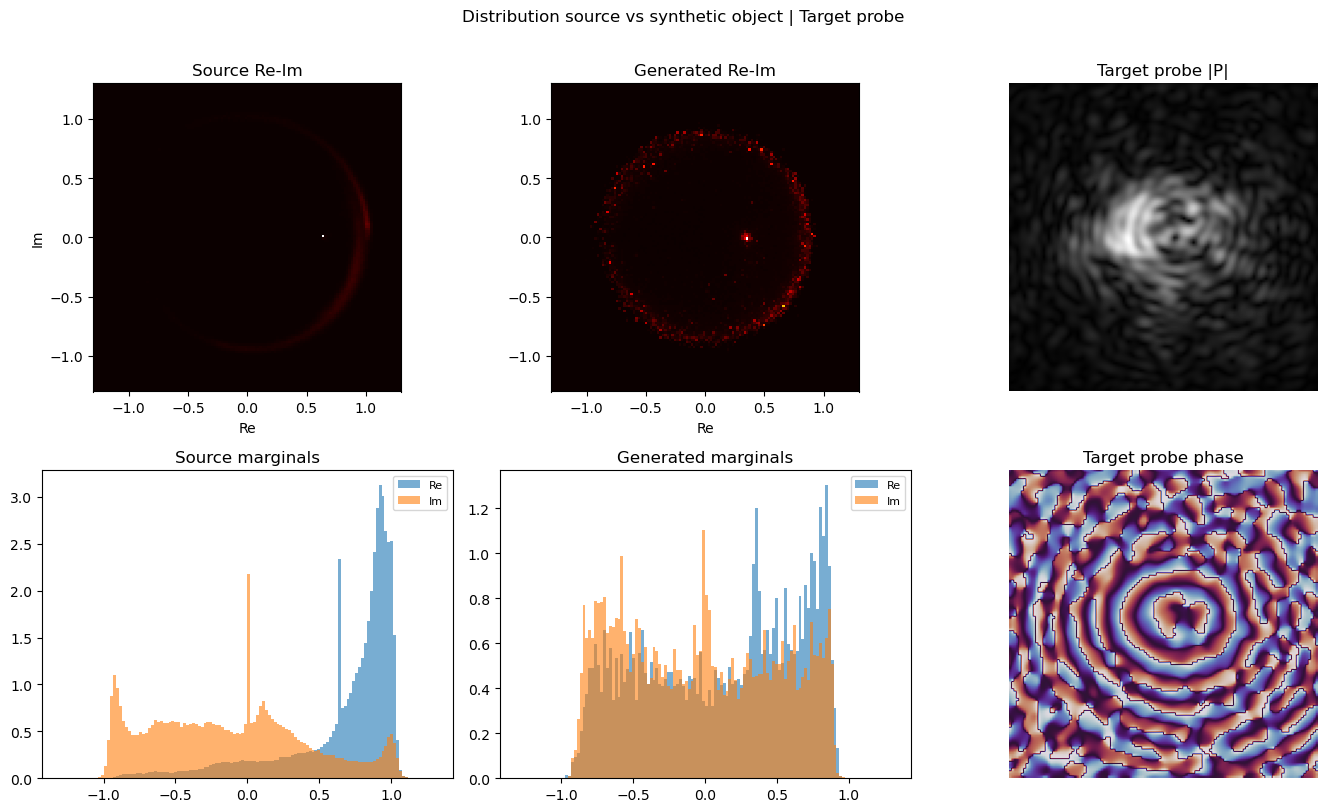

In [26]:
# Generate one synthetic object for visualization
# xd_sample = create_dead_leaves_reim_gmm(image_size, xd_obj_arg)
xd_sample = methods['dead_leaves_hist']()

# Crop source object to same canvas size for fair comparison
h, w = image_size
dist_crop = dist_obj[
    dist_obj.shape[0] // 2 - h // 2 : dist_obj.shape[0] // 2 + h // 2,
    dist_obj.shape[1] // 2 - w // 2 : dist_obj.shape[1] // 2 + w // 2,
]

# Show first probe mode if multi-mode
probe_display = target_probe[0] if target_probe.ndim == 3 else target_probe

hist_range = [[-1.3, 1.3], [-1.3, 1.3]]
bins = 128

fig, axes = plt.subplots(2, 3, figsize=(14, 8))

# Row 0: 2D Re-Im histograms + probe amplitude
axes[0, 0].hist2d(dist_crop.real.ravel(), dist_crop.imag.ravel(),
                  bins=bins, range=hist_range, cmap='hot')
axes[0, 0].set_title('Source Re-Im')
axes[0, 0].set_xlabel('Re'); axes[0, 0].set_ylabel('Im')
axes[0, 0].set_aspect('equal')

axes[0, 1].hist2d(xd_sample.real.ravel(), xd_sample.imag.ravel(),
                  bins=bins, range=hist_range, cmap='hot')
axes[0, 1].set_title('Generated Re-Im')
axes[0, 1].set_xlabel('Re')
axes[0, 1].set_aspect('equal')

axes[0, 2].imshow(np.abs(probe_display), cmap='gray')
axes[0, 2].set_title('Target probe |P|')
axes[0, 2].axis('off')

# Row 1: marginals + probe phase
for col, (arr, label) in enumerate([(dist_crop, 'Source'), (xd_sample, 'Generated')]):
    axes[1, col].hist(arr.real.ravel(), bins=bins, range=(-1.3, 1.3),
                      alpha=0.6, label='Re', density=True)
    axes[1, col].hist(arr.imag.ravel(), bins=bins, range=(-1.3, 1.3),
                      alpha=0.6, label='Im', density=True)
    axes[1, col].set_title(f'{label} marginals')
    axes[1, col].legend(fontsize=8)

axes[1, 2].imshow(np.angle(probe_display), cmap='twilight', vmin=-np.pi, vmax=np.pi)
axes[1, 2].set_title('Target probe phase')
axes[1, 2].axis('off')

plt.suptitle('Distribution source vs synthetic object | Target probe', y=1.01)
plt.tight_layout()
plt.show()

### Simulate and save cross-dataset synthetic experiments

In [29]:
# Dispatch table for object generation methods
xd_gen_funcs = {
    'dead_leaves_reim_gmm': lambda: create_dead_leaves_reim_gmm(image_size, xd_obj_arg),
    'dead_leaves_reim_hist': lambda: create_dead_leaves_v3(
        image_size, {**xd_obj_arg, 'mode': 'histogram'}, histogram=xd_histogram,
    ),
    'white_noise_clustered_reim': lambda: create_white_noise_clustered_reim(image_size, xd_obj_arg),
}

print(f'Generating {n_objects} objects with {obj_method}...')
xd_obj_list = [xd_gen_funcs[obj_method]() for _ in range(n_objects)]

# Build probe list and simulation args
data_config = DataConfig(N=N)
probe_list = [target_probe] * n_objects
probe_name_idx = [0] * n_objects
probe_arg = {'probe_name_idx': probe_name_idx, 'beamstop_diameter': 4}

# Prepare output directory
if not os.path.exists(save_dir):
    os.makedirs(save_dir)
else:
    remove_all_files(save_dir)

# Simulate diffraction and save (scan steps from probe reference)
simulate_multiple_experiments(
    xd_obj_list, probe_list, diff_per_object,
    image_size, data_config, probe_arg, save_dir,
    scan_step_sizes=xd_scan_steps,
)

print(f'\nSaved {n_objects} experiments to {save_dir}')
print(f'  Distribution from: {distribution_source_path}')
print(f'  Probe + scan from: {probe_source_path}')

Generating 4 objects with dead_leaves_reim_hist...
create_dead_leaves_v3 (mode=histogram): generated (1085, 1070) object
create_dead_leaves_v3 (mode=histogram): generated (1085, 1070) object
create_dead_leaves_v3 (mode=histogram): generated (1085, 1070) object
create_dead_leaves_v3 (mode=histogram): generated (1085, 1070) object
----Beginning simulation for experiment 0----
Anisotropic grid: nx=84, ny=84, x_step=11.35, y_step=11.53, ratio=0.984 (target=0.985)
Beginning simulation...
Processing 7000 images in batches of 1000...
  Getting image patches...


OutOfMemoryError: CUDA out of memory. Tried to allocate 12.98 GiB. GPU 0 has a total capacity of 11.60 GiB of which 340.19 MiB is free. Process 2671110 has 262.00 MiB memory in use. Process 2670534 has 2.07 GiB memory in use. Including non-PyTorch memory, this process has 8.84 GiB memory in use. Of the allocated memory 8.66 GiB is allocated by PyTorch, and 11.84 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)